# Predicting housing prices in King County, Washington

#### Kyan Lee and Rene Vega

In this notebook, we will be predicting the price of a selling house in King County, Washington based on the previous data of sold houses in the area. We will be taking factors such as square footage, number of bedrooms, and condition grading into account. We will be using KNN regression as well as linear regression and comparing how each model performs in predicting pricing.

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import tree
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# suppress futurewarnings only
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [153]:
sns.set_theme(context='notebook', style='whitegrid')

# set default plot size
plt.rcParams['figure.figsize'] = 6,4

In [154]:
display(HTML("<style>.container { width:90% !important; }</style>"))

In [155]:
input_file = "kc_house_data.csv"
df = pd.read_csv(input_file)

## Data Preprocessing

Here, we will remove unique variables for each house as well as certain attributes that are not very helpful to our model. We will also drop the null rows as they are not too impactful to the data.

In [156]:
df.drop(['id', 'lat','long','yr_renovated', 'view', 'waterfront', 'zipcode', 'date'], axis=1, inplace=True)
df=df.dropna()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,3,7,1180,0.0,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,3,7,2170,400.0,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,3,6,770,0.0,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,5,7,1050,910.0,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,3,8,1680,0.0,1987,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,360000.0,3,2.50,1530,1131,3.0,3,8,1530,0.0,2009,1530,1509
21593,400000.0,4,2.50,2310,5813,2.0,3,8,2310,0.0,2014,1830,7200
21594,402101.0,2,0.75,1020,1350,2.0,3,7,1020,0.0,2009,1020,2007
21595,400000.0,3,2.50,1600,2388,2.0,3,8,1600,0.0,2004,1410,1287


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21597 non-null  float64
 1   bedrooms       21597 non-null  int64  
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  int64  
 4   sqft_lot       21597 non-null  int64  
 5   floors         21597 non-null  float64
 6   condition      21597 non-null  int64  
 7   grade          21597 non-null  int64  
 8   sqft_above     21597 non-null  int64  
 9   sqft_basement  21597 non-null  object 
 10  yr_built       21597 non-null  int64  
 11  sqft_living15  21597 non-null  int64  
 12  sqft_lot15     21597 non-null  int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 2.1+ MB


# Data Exploration

Now, let's see what we are working with. It is important to see what trends we can find in the data so that we have an idea of what we are trying to predict.

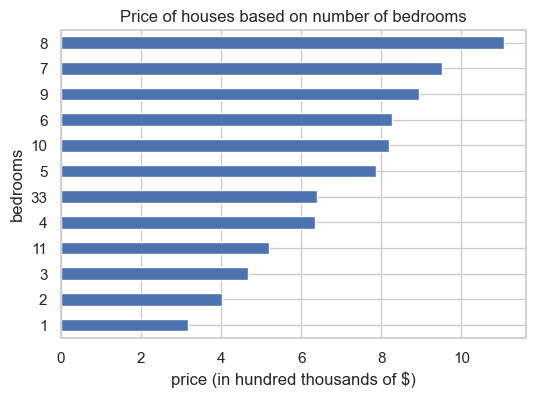

In [158]:
(df.groupby(df['bedrooms'])['price'].mean()/100000).sort_values().plot.barh()
plt.title("Price of houses based on number of bedrooms")
plt.xlabel("price (in hundred thousands of $)");

Here we can see that on average, houses with 7-9 bedrooms are selling for a higher price than other houses. This is taking into account that the general number of houses with more than 3 bedrooms can be a lot smaller than those with less.

In [15]:
df.sample(2000).plot.scatter(x='sqft_living_scaled', y='price_scaled', alpha=0.7)
plt.title('Price based  on squared footage')
plt.xlabel('square footage (in thousands)')
plt.ylabel('price (in 100k $)')
plt.xlim(0,8);

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,sqft_living15,sqft_lot15
3169,364000.0,4,2.25,1750,10270,1.5,4,8,1750,0.0,1968,1750,10127
20062,544999.0,4,2.50,2710,6937,2.0,3,7,2710,0.0,2009,2380,5866
10170,804000.0,5,3.50,2770,9305,2.0,3,9,2770,0.0,1985,2520,9773
4315,432500.0,3,2.50,2390,6435,1.0,3,8,1600,790.0,1978,2020,7300
1131,269000.0,3,1.00,1690,4250,1.0,3,7,1020,670.0,1967,1820,8865
16447,254000.0,3,1.00,1010,7384,1.0,5,6,1010,0.0,1943,1010,8000
14850,575000.0,4,2.25,2060,12155,1.0,4,8,2060,0.0,1968,2360,8625
9758,366000.0,3,1.75,1510,8301,1.0,3,7,1510,?,1967,1460,7910
16811,2500000.0,4,4.50,4300,19844,2.0,3,11,4300,0.0,1985,3070,19845
15351,120750.0,3,1.75,1140,9628,1.0,4,7,1140,0.0,1969,1510,9633


We can see the general increase in price as these factors increase, so what we want to look for in our model is this same trend of increasing bedroom number or square footage will mean increasing price. This makes a lot of logical sense, so we should not run into too many problems with our predictions. In general, it is easy for humans to approximate the direction in which price is moving, so let's see how well the computer does.

# Machine Learning

Starting off with a normal test/train split, we will set the predictors we will be using as well as some baseline calculations to get an idea of what we are looking for.

### Machine Learning

In [30]:
predictors = ['bedrooms', 'condition', 'grade']
target = 'price'
X = df[predictors].values
y = df[target].values

# split the data into training and testing sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state = 42)

# compute the most common price in the training set
most_common_price = pd.Series(y_train).value_counts().index[0]
print("Most common price in the training set:", most_common_price)

# compute and print the baseline accuracy
baseline_accuracy = (y_train == most_common_price).mean()
print(f"Baseline accuracy: {baseline_accuracy:.3f}")

# scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create classifier object
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)

# predicted prices based on the selected predictor variables
y_pred = clf.predict(X_test)

# compute the root mean squared error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.3f}")

# printing the first 10 predicted prices
print(f'First 10 predicted prices: {y_pred[:10]}')

Most common price in the training set: 350000.0
Baseline accuracy: 0.008
Model accuracy: 0.005
First 10 predicted prices: [160000. 235000. 245000. 410000. 350000. 240000. 175000. 799950. 212000.
 245000.]
